<h1 style="font-size:2.8em; color:#1976d2; font-weight:bold">BÀI TOÁN PHÂN LOẠI CÁC LOẠI KHOÁNG THẠCH THÔNG QUA HÌNH ẢNH </h1>

# **📘 GIỚI THIỆU BÀI TOÁN**

***BÀI TẬP LỚN 3: HỌC MÁY VỚI DỮ LIỆU DẠNG ẢNH (IMAGE DATA)***

* **Giảng viên hướng dẫn**  
  * **Giảng viên: TS.Lê Thành Sách**

* **Nhóm MNTV:**
  * Tên: Huỳnh Đức Nhân - MSSV:2312420
  * Tên: Nguyễn Thiện Minh - MSSV: 2312097
  * Tên: Nguyễn Lưu Khánh Trình - MSSV: 2313638
  * Tên: Lê Công Vinh - MSSV: 2313912


* **Giới thiệu bài toán**
  * Xây dựng pipeline Học Sâu (Deep Learning) cho dữ liệu dạng ảnh, ở đây nhóm sử dụng bộ dữ liệu Minerals Identification Dataset với hơn 960 hình ảnh với các định dạng khác nhau.

  * Mục tiêu của các mô hình là phân loại các loại khoáng thạch khác nhau dựa trên hình ảnh có sẵn trong tập dữ liệu.

  * Minerals Identification Dataset chứa hơn 960 hình ảnh khoáng thạch khác nhau như Malachiye, Bornite, Pyrite,... với các định dạng là .png, .jpeg, .jpg.

  * Thông tin về bộ dữ liệu:
    * Tổng số mẫu: 961 file.
    * Format dữ liệu: Dữ liệu hình ảnh.
    * Định dạng: .png, .jpeg, .jpg
    * Link dataset: [Kaggle - Minerals Identification Dataset](https://www.kaggle.com/datasets/asiedubrempong/minerals-identification-dataset)


*  **Mục tiêu của bài toán**
    * Xây dựng pipeline Học Sâu hoàn chỉnh: Từ khâu tiền xử lý (tải dữ liệu, biến đổi ảnh (transforms), tăng cường dữ liệu (augmentation)) đến việc xây dựng, huấn luyện và đánh giá mô hình.
    * Xây dựng và huấn luyện mô hình CNN: Triển khai một kiến trúc Mạng Nơ-ron Tích chập (CNN) tùy chỉnh (custom) bằng thư viện **PyTorch** và huấn luyện mô hình này từ đầu (training from scratch).
    * ***Phân tích chi tiết***: Đánh giá hiệu suất của mô hình thông qua các chỉ số đánh giá phân loại như **Accuracy (Độ chính xác)**, **Precision**, **Recall**, **F1-Score** và trực quan hóa kết quả bằng **Confusion Matrix (Ma trận nhầm lẫn)**.


* **Các mô hình sẽ được triển khai:**
    * ***Mạng Nơ-ron Tích chập (CNN)
    *
****

# **📌 Các thiết lập ban đầu**

## 📚 Giới thiệu các thư viện sử dụng

Trong quá trình xây dựng và huấn luyện mô hình **phân loại ảnh**, nhóm đã sử dụng nhiều thư viện Python phổ biến, hỗ trợ mạnh mẽ cho việc xử lý tệp tin, tiền xử lý dữ liệu hình ảnh, cũng như xây dựng các mô hình Deep Learning và Machine Learning.

## 1. Tiện ích cơ bản (Python & Hệ thống)
* `os`: Tương tác với hệ điều hành (đọc, ghi file, tạo thư mục).
* `zipfile`: Đọc và giải nén file ZIP.
* `random`: Tạo số ngẫu nhiên.
* `glob`: Tìm kiếm file theo mẫu (ví dụ: `*.jpg`).
* `shutil`: Tiện ích nâng cao về file (sao chép, di chuyển, xóa thư mục).
* `collections (defaultdict, Counter)`: Cung cấp các cấu trúc dữ liệu hữu ích (từ điển tự động gán giá trị mặc định, bộ đếm phần tử).
* `time`: Đo lường thời gian thực thi.
* `warnings`: Quản lý và ẩn các thông báo cảnh báo.

## 2. Xử lý dữ liệu & Trực quan hóa
* `numpy (np)`: Thư viện nền tảng cho tính toán số học, làm việc với mảng (matrix) hiệu suất cao.
* `pandas (pd)`: Đọc, ghi và xử lý dữ liệu dạng bảng (như CSV, Excel).
* `matplotlib.pyplot (plt)` & `matplotlib.image (mpimg)`: Thư viện chính để vẽ biểu đồ và hiển thị hình ảnh.
* `seaborn (sns)`: Thư viện xây dựng trên Matplotlib, giúp vẽ biểu đồ thống kê đẹp hơn.
* `PIL (Image)`: Thư viện mạnh mẽ để mở, xử lý và lưu nhiều định dạng hình ảnh.

## 3. Thư viện Học Sâu - PyTorch
* `torch`: Thư viện chính của PyTorch.
* `torch.nn (nn)` & `torch.nn.functional (F)`: Các khối xây dựng Mạng Nơ-ron (các lớp CNN, hàm kích hoạt, hàm mất mát).
* `torch.optim (optim)`: Chứa các thuật toán tối ưu hóa (ví dụ: Adam, SGD).
* `torch.utils.data (DataLoader, ...Sampler)`: Công cụ để tải và chia dữ liệu (tạo batch, xáo trộn dữ liệu).
* `torchvision`: Gói tiện ích của PyTorch dành riêng cho xử lý ảnh.
    * `torchvision.datasets (ImageFolder)`: Tải bộ dữ liệu ảnh có sẵn từ các thư mục.
    * `torchvision.transforms`: Các phép biến đổi và tăng cường hình ảnh (thay đổi kích thước, cắt, xoay).
    * `torchvision.models`: Chứa các kiến trúc mô hình nổi tiếng đã được huấn luyện trước (VGG16, ResNet, EfficientNet).

## 4. Thư viện Học Sâu - TensorFlow/Keras
*(Dùng cho phương pháp trích xuất đặc trưng hoặc so sánh)*
* `tensorflow (tf)`: Thư viện chính của TensorFlow.
* `tensorflow.keras.preprocessing.image (ImageDataGenerator)`: Tải và tăng cường dữ liệu ảnh cho Keras.
* `tensorflow.keras.applications (VGG16, ResNet50, ...)`: Các mô hình Keras đã được huấn luyện trước.
* `tensorflow.keras.models (Model)` & `layers (Input)`: Các khối xây dựng mô hình trong Keras.

## 5. Thư viện Học máy truyền thống - Scikit-learn
*(Dùng cho phương pháp trích xuất đặc trưng)*
* `sklearn.model_selection (train_test_split)`: Chia dữ liệu thành tập huấn luyện và tập kiểm tra.
* `sklearn.linear_model (LogisticRegression)`: Mô hình Hồi quy Logistic.
* `sklearn.svm (SVC)`: Mô hình Support Vector Machine (SVM) để phân loại.
* `sklearn.ensemble (RandomForestClassifier)`: Mô hình Rừng ngẫu nhiên (Random Forest).
* `sklearn.metrics (accuracy_score, ...)`: Các hàm để đo lường độ chính xác và đánh giá mô hình.



**Cấu hình bổ sung:** Nhóm định nghĩa hằng số `IMG_SIZE = (224, 224)` để đảm bảo tất cả hình ảnh đầu vào đều được điều chỉnh về kích thước chuẩn, phù hợp với yêu cầu của các mô hình CNN pre-trained.

In [ ]:
import os
import zipfile
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image
from glob import glob
from collections import defaultdict
from PIL import Image
import warnings
import shutil
from collections import Counter
import time
import torch.optim as optim
from torch.utils.data import SubsetRandomSampler
from torch.utils.data import DataLoader, SubsetRandomSampler
from torch.utils.data import DataLoader, SubsetRandomSampler, WeightedRandomSampler

import torchvision.models as models
from torchvision.models import EfficientNet_B0_Weights

from torchvision.datasets import ImageFolder
from torchvision import datasets, transforms
import torch
import torch.nn as nn
import torch.nn.functional as F

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

IMG_SIZE = (224, 224)

# **📥 Tải và kiểm tra dữ liệu**

## *Tải dữ liệu*

Đầu tiên, nhóm tiến hành tải bộ dữ liệu ảnh Minerals Identification Dataset từ **Kaggle** thông qua thư viện `kagglehub` bằng cách sử dụng `kagglehub.dataset_download(...)` để tải bộ dữ liệu từ Kaggle.


Bộ dữ liệu được tổ chức theo cấu trúc thư mục. Trong đó, **mỗi thư mục con đại diện cho một lớp (class)**, tức là một loại khoáng sản cụ thể, chứa tất cả các hình ảnh thuộc về lớp đó.

Dữ liệu của chúng tôi bao gồm **7 lớp khoáng sản** riêng biệt, tạo nên bài toán phân loại 7 nhóm:

* **Biotite**
* **Bornite**
* **Chrysocolla**
* **Malachite**
* **Muscovite**
* **Pyrite**
* **Quartz**



In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("asiedubrempong/minerals-identification-dataset")

print("Path to dataset files:", path)

100%|██████████| 230M/230M [00:01<00:00, 156MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/asiedubrempong/minerals-identification-dataset/versions/1



Hiển thị các ảnh mẫu:


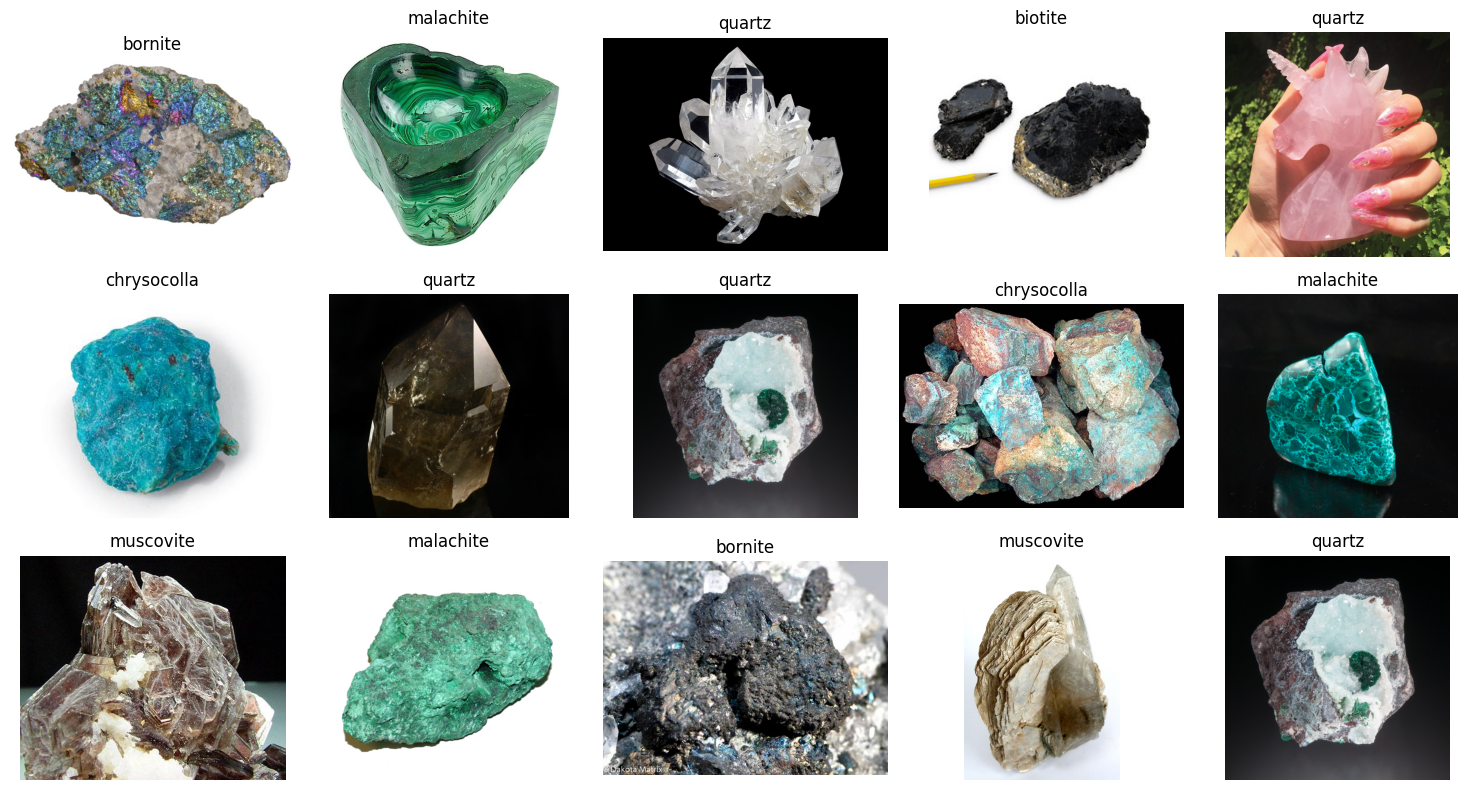

In [ ]:
data_dir = os.path.join(path, 'minet')
class_names = os.listdir(data_dir)

# Hàm để hiển thị ảnh mẫu
def show_sample_images(directory, class_names, num_rows=3, num_cols=5):
    plt.figure(figsize=(15, 8))
    for i in range(num_rows * num_cols):
        # Chọn ngẫu nhiên 1 lớp
        random_class = random.choice(class_names)
        class_path = os.path.join(directory, random_class)

        # Chọn ngẫu nhiên 1 ảnh trong lớp đó
        try:
            random_image = random.choice(os.listdir(class_path))
            image_path = os.path.join(class_path, random_image)

            # Đọc và hiển thị ảnh
            img = mpimg.imread(image_path)
            plt.subplot(num_rows, num_cols, i + 1)
            plt.imshow(img)
            plt.title(random_class)
            plt.axis('off')
        except (IOError, IndexError):
            # Bỏ qua nếu thư mục rỗng hoặc file ảnh bị lỗi
            pass
    plt.tight_layout()
    plt.show()

print("\nHiển thị các ảnh mẫu:")
show_sample_images(data_dir, class_names)

# **📊 EDA - Khám phá dữ liệu**

## 🔍 Phân tích Tổng quan Bộ Dữ liệu Khoáng sản

Bộ dữ liệu **Minerals Identification Dataset** bao gồm tổng cộng **khoảng 960 mẫu** hình ảnh. Việc phân tích cấu trúc dữ liệu cho thấy sự đa dạng về định dạng tệp và sự mất cân bằng về số lượng mẫu giữa 7 lớp khoáng sản.

Bộ dữ liệu được chia thành **7 lớp** khoáng sản. Phân tích số lượng mẫu cho thấy rõ hiện tượng **mất cân bằng dữ liệu (data imbalance)**:

| Lớp Khoáng sản | Số lượng Mẫu |
| :--- | :--- |
| **Malachite** | 236 |
| **Bornite** | 173 |
| **Chrysocolla** | 164 |
| **Quartz** | 143 |
| **Pyrite** | 98 |
| **Muscovite** | 77 |
| **Biotite** | 68 |

**Nhận xét:** Có sự chênh lệch lớn giữa lớp có số lượng mẫu nhiều nhất (**Malachite**, 236 mẫu) và ít nhất (**Biotite**, 68 mẫu).







Thống kê số lượng ảnh mỗi lớp:
         Class  Count
0    malachite    236
2      bornite    173
3  chrysocolla    164
1       quartz    143
6       pyrite     98
4    muscovite     77
5      biotite     68


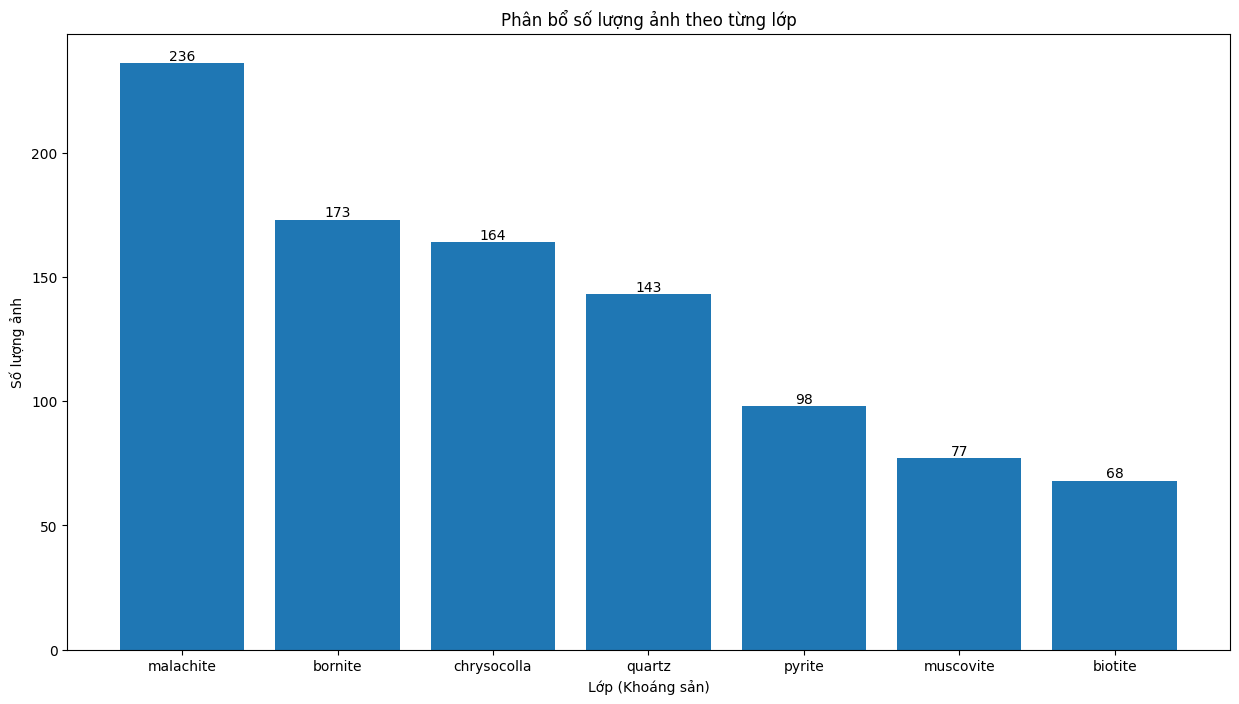

In [ ]:
# Đếm số lượng ảnh trong mỗi lớp
image_count_per_class = []
for class_name in class_names:
    class_path = os.path.join(data_dir, class_name)
    # Kiểm tra xem có phải là thư mục không
    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        image_count_per_class.append({'Class': class_name, 'Count': count})

# Chuyển sang DataFrame (Pandas) để dễ xem
df_class_counts = pd.DataFrame(image_count_per_class)
df_class_counts = df_class_counts.sort_values('Count', ascending=False)

print("\nThống kê số lượng ảnh mỗi lớp:")
print(df_class_counts.head(10))


# Vẽ biểu đồ để trực quan hóa
plt.figure(figsize=(15, 8))
bars = plt.bar(df_class_counts['Class'], df_class_counts['Count'])
plt.title('Phân bổ số lượng ảnh theo từng lớp')
plt.xlabel('Lớp (Khoáng sản)')
plt.ylabel('Số lượng ảnh')

# ----- BẠN CHỈ CẦN THÊM ĐOẠN NÀY VÀO -----
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval,
             int(yval),
             ha='center',
             va='bottom')
# ------------------------------------------

plt.show()


## 📝 Nhận xét
Kết quả thống kê cho thấy phần lớn dữ liệu (hơn 950 tệp) là các định dạng ảnh hợp lệ (.jpg, .png, .jpeg), điều này rất tốt cho việc huấn luyện. Tuy nhiên, bộ dữ liệu đang tồn tại các tệp "rác" hoặc bị lỗi (như .com, .bo, .gif và một tệp có tên bị dị dạng) có khả năng gây lỗi nghiêm trọng khi tải dữ liệu. Do đó, cần phải thực hiện bước dọn dẹp, xóa bỏ các tệp không hợp lệ này trước khi đưa vào pipeline huấn luyện mô hình.


Thống kê số lượng tệp theo định dạng:
                       Định dạng  Số lượng
                             jpg       934
                            jpeg         7
                             png        15
                             com         1
                              bo         2
                             gif         1
 geocentral-chrysocolla-roughjpg         1
----------------------------------------


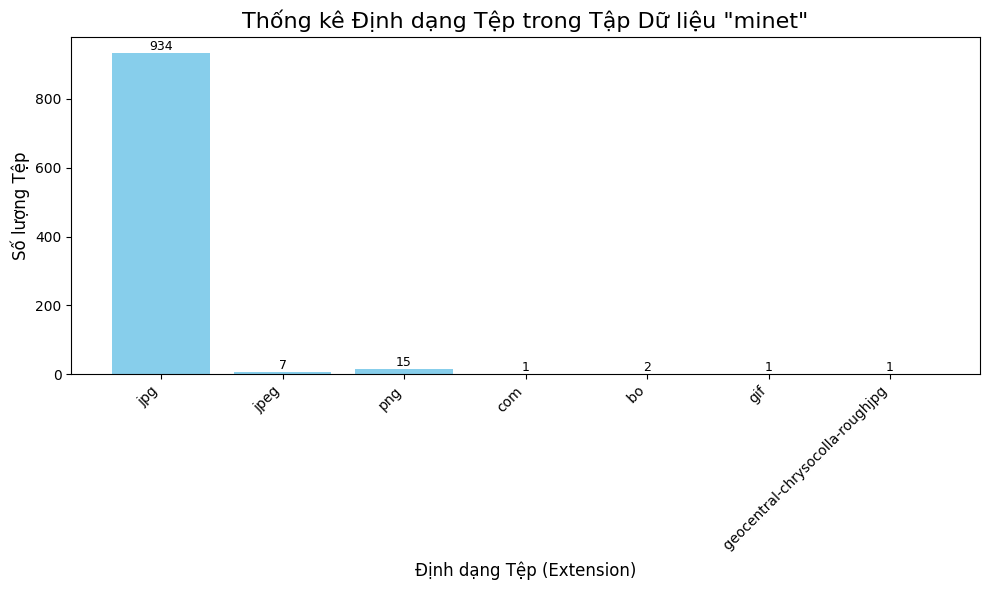

In [ ]:
extension_counts = defaultdict(int)
for root, dirs, files in os.walk(data_dir):
    for file in files:
        # Tách lấy phần mở rộng (đuôi) tệp
        _, ext = os.path.splitext(file)

        # Chuẩn hóa:
        ext = ext.lower().lstrip('.')

        # Nếu tệp không có đuôi (ví dụ: file ẩn)
        if not ext:
            ext = 'Không có đuôi'

        # Tăng bộ đếm cho định dạng này
        extension_counts[ext] += 1

# 3. Chuyển sang DataFrame để dễ dàng sắp xếp và vẽ biểu đồ
df_counts = pd.DataFrame(list(extension_counts.items()), columns=['Định dạng', 'Số lượng'])

print("Thống kê số lượng tệp theo định dạng:")
print(df_counts.to_string(index=False))
print("-" * 40)

# 4. Vẽ biểu đồ
plt.figure(figsize=(10, 6))

# Sử dụng dữ liệu từ DataFrame (bây giờ đã không còn sắp xếp)
bars = plt.bar(df_counts['Định dạng'], df_counts['Số lượng'], color='skyblue')

plt.title('Thống kê Định dạng Tệp trong Tập Dữ liệu "minet"', fontsize=16)
plt.xlabel('Định dạng Tệp (Extension)', fontsize=12)
plt.ylabel('Số lượng Tệp', fontsize=12)

# Xoay nhãn trục X nếu có nhiều định dạng
plt.xticks(rotation=45, ha='right')

# Thêm số lượng trên đỉnh các cột
for bar in bars:
    yval = bar.get_height()
    # Hiển thị số lượng ngay trên đỉnh cột
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), ha='center', va='bottom', fontsize=9)

plt.tight_layout() # Tự động điều chỉnh layout cho vừa vặn
plt.show()

## 📝 Nhận xét về các định dạng trong tập dữ liệu
Trong dữ liệu hiện tại tồn tại 8 tệp "rác" (file hệ thống như .ipynb_checkpoints, file .gif, .bo...) đã được xác định và sẽ bị bỏ qua. Quan trọng hơn, 100% các tệp ảnh hợp lệ (.png, .jpg, .jpeg) đều ở trong tình trạng tốt và không bị hỏng. Điều này đảm bảo rằng quá trình tải dữ liệu (data loading) sẽ diễn ra mượt mà mà không gặp lỗi "corrupted file".

## 📝 Nhận xét về kênh màu
Hiện tại, xét về kênh màu, đa số là RGB (941 ảnh), nhưng sự xuất hiện của các ảnh RGBA (có kênh trong suốt), P (ảnh hệ màu palette), và L (ảnh xám) sẽ gây lỗi cho mô hình CNN (vốn mong đợi 3 kênh). Do đó, sẽ phải thực hiện một bước chuyển đổi tất cả ảnh sang chế độ RGB

## 📝 Nhận xét về kích thước ảnh
Về kích thước ảnh, thống kê cho thấy sự không đồng nhất nghiêm trọng, với nhiều kích cỡ và tỷ lệ khung hình khác nhau (ví dụ: 1000x1000, 800x600, 300x300). Với sự đa dạng về kcihs thước đó, để đảm bảo mô hình đạt được kết quả tốt nhất, từ đó phải chuẩn hóa kích thước đầu vào.

Tổng cộng: 8 file bị bỏ qua (không phải .png, .jpg, .jpeg).
Tổng cộng: 0 file ảnh (có đuôi hợp lệ) bị hỏng.

DANH SÁCH CÁC FILE BỊ BỎ QUA (đuôi tệp không hợp lệ):
/root/.cache/kagglehub/datasets/asiedubrempong/minerals-identification-dataset/versions/1/minet/malachite/.ipynb_checkpoints
/root/.cache/kagglehub/datasets/asiedubrempong/minerals-identification-dataset/versions/1/minet/malachite/132. malachite+butterfly+%2f+krista-mitchell.com
/root/.cache/kagglehub/datasets/asiedubrempong/minerals-identification-dataset/versions/1/minet/quartz/.ipynb_checkpoints
/root/.cache/kagglehub/datasets/asiedubrempong/minerals-identification-dataset/versions/1/minet/bornite/9. bo
/root/.cache/kagglehub/datasets/asiedubrempong/minerals-identification-dataset/versions/1/minet/bornite/114. bornite.gif
/root/.cache/kagglehub/datasets/asiedubrempong/minerals-identification-dataset/versions/1/minet/bornite/42. bo
/root/.cache/kagglehub/datasets/asiedubrempong/minerals-identification-dataset/versions/1/min

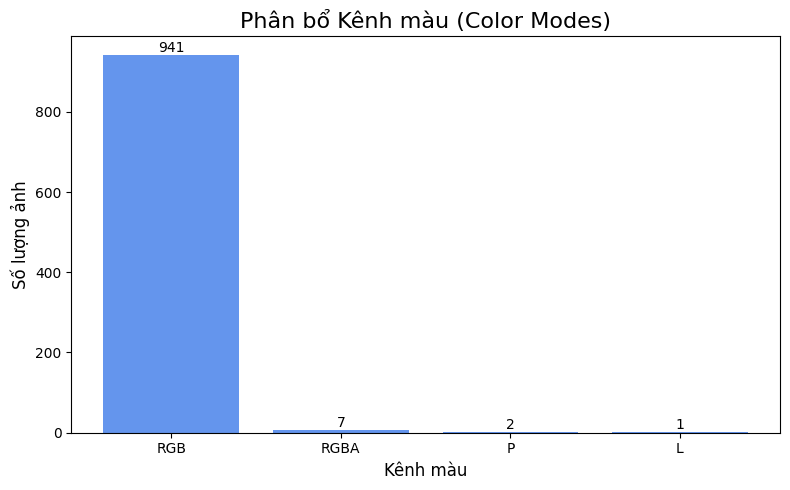


PHÂN TÍCH KÍCH THƯỚC ẢNH
Top 10 kích thước ảnh phổ biến nhất:
(1000, 1000)    37
(800, 600)      30
(300, 300)      17
(1024, 768)     16
(1000, 700)     14
(1024, 1024)    14
(500, 500)      12
(340, 270)      12
(1300, 956)     12
(400, 400)      11
Name: count, dtype: int64


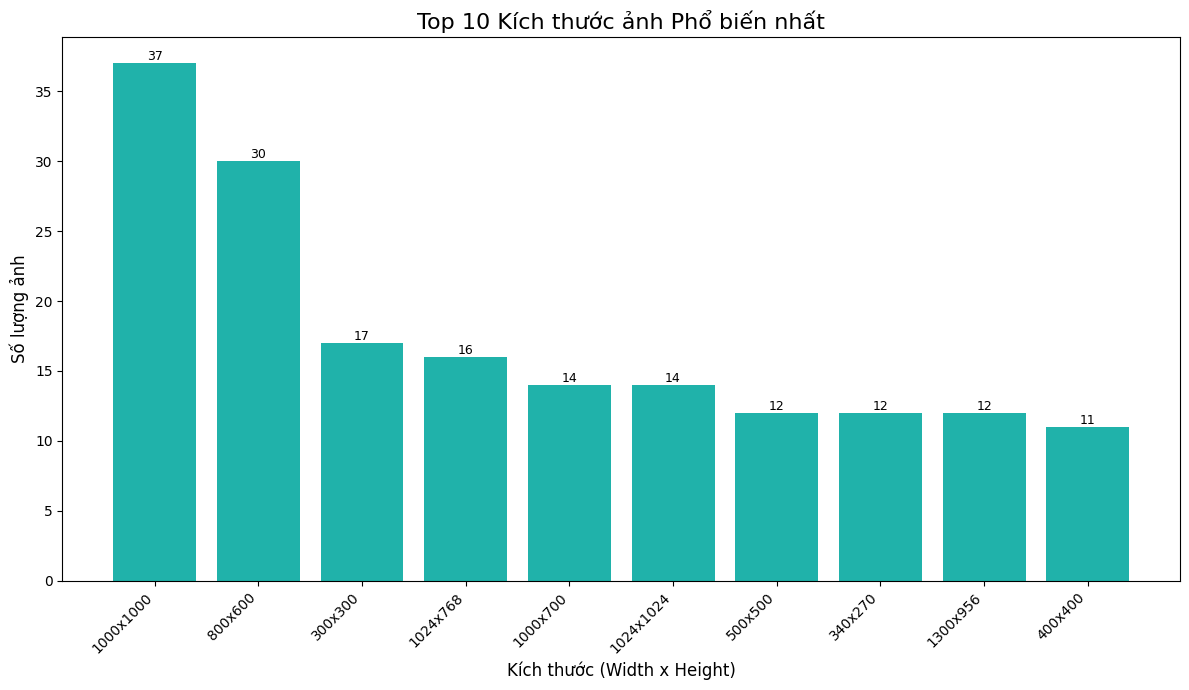

In [ ]:
import os
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

# --- Giả định các biến data_dir và class_names đã tồn tại ---
# data_dir = "..."
# class_names = os.listdir(data_dir)
# -------------------------------------------------------------


# --- Bắt đầu EDA (Kích thước & Kênh màu) ---

all_sizes = []
all_modes = []
corrupted_files = []
skipped_files = []

VALID_IMAGE_EXTENSIONS = {'.png', '.jpg', '.jpeg'}

# Quét qua tất cả các file
for cls in class_names:
    class_path = os.path.join(data_dir, cls)
    if not os.path.isdir(class_path):
        continue

    for img_file in os.listdir(class_path):
        img_path = os.path.join(class_path, img_file)

        _, file_extension = os.path.splitext(img_file)
        file_extension = file_extension.lower()

        if file_extension in VALID_IMAGE_EXTENSIONS:
            try:
                with Image.open(img_path) as img:
                    all_sizes.append(img.size)
                    all_modes.append(img.mode)
            except Exception as e:
                corrupted_files.append(img_path)
        else:
            skipped_files.append(img_path)


print(f"Tổng cộng: {len(skipped_files)} file bị bỏ qua (không phải .png, .jpg, .jpeg).")
print(f"Tổng cộng: {len(corrupted_files)} file ảnh (có đuôi hợp lệ) bị hỏng.")

# (Phần in ra file hỏng và file bỏ qua giữ nguyên như code của bạn)
# ...
if len(skipped_files) > 0:
    print("\n" + "="*30)
    print("DANH SÁCH CÁC FILE BỊ BỎ QUA (đuôi tệp không hợp lệ):")
    print("="*30)
    for f_path in skipped_files[:10]:
        print(f_path)
    if len(skipped_files) > 10:
        print(f"(và {len(skipped_files) - 10} file khác...)")
    print("\nLý do: Các file này không có đuôi .png, .jpg, hoặc .jpeg.")

if len(corrupted_files) > 0:
    print("\n" + "="*30)
    print("DANH SÁCH CÁC FILE ẢNH BỊ HỎNG (Corrupted):")
    print("="*30)
    for f_path in corrupted_files:
        print(f_path)
    print("\nLý do: Các file này CÓ đuôi ảnh hợp lệ nhưng nội dung file bị lỗi.")
else:
    print("Không tìm thấy file ảnh hỏng nào (.png, .jpg, .jpeg).")

# --- 1. Phân tích Kênh màu (Số kênh) ---
print("\n" + "="*30)
print("PHÂN TÍCH KÊNH MÀU (Color Modes)")
print("="*30)
if len(all_modes) > 0:
    mode_counts = pd.Series(all_modes).value_counts()
    print(mode_counts)
else:
    print("Không tìm thấy ảnh hợp lệ để phân tích.")

    # --- 1. Vẽ biểu đồ cho KÊNH MÀU ---
if len(all_modes) > 0:
    plt.figure(figsize=(8, 5))

    # Dùng .index cho trục X (tên mode) và .values cho trục Y (số lượng)
    bars = plt.bar(mode_counts.index, mode_counts.values, color='cornflowerblue')

    plt.title('Phân bổ Kênh màu (Color Modes)', fontsize=16)
    plt.xlabel('Kênh màu', fontsize=12)
    plt.ylabel('Số lượng ảnh', fontsize=12)

    # Thêm số lượng trên đỉnh các cột
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval),
                 ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

# --- 2. Phân tích Kích thước ảnh ---
print("\n" + "="*30)
print("PHÂN TÍCH KÍCH THƯỚC ẢNH")
print("="*30)
if len(all_sizes) > 0:
    size_counts = pd.Series(all_sizes).value_counts()
    print("Top 10 kích thước ảnh phổ biến nhất:")
    print(size_counts.head(10))
else:
    print("Không tìm thấy ảnh hợp lệ để phân tích.")

# --- 2. Vẽ biểu đồ cho KÍCH THƯỚC ẢNH (Top 10) ---
if len(all_sizes) > 0:
    # Chỉ lấy top 10 để vẽ
    top_10_sizes = size_counts.head(10)

    # Chuyển đổi kích thước (tuple) thành chuỗi (string) để hiển thị đẹp hơn
    # Ví dụ: (224, 224) -> "224x224"
    labels = [f"{w}x{h}" for w, h in top_10_sizes.index]
    values = top_10_sizes.values

    plt.figure(figsize=(12, 7))
    bars = plt.bar(labels, values, color='lightseagreen')

    plt.title('Top 10 Kích thước ảnh Phổ biến nhất', fontsize=16)
    plt.xlabel('Kích thước (Width x Height)', fontsize=12)
    plt.ylabel('Số lượng ảnh', fontsize=12)

    # Xoay nhãn trục X để không bị chồng chéo
    plt.xticks(rotation=45, ha='right')

    # Thêm số lượng trên đỉnh các cột
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval),
                 ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

## 📝 Xử lý các file không cần thiết, kênh màu và kích thước ảnh

In [ ]:
# Tắt các cảnh báo từ PIL
Image.MAX_IMAGE_PIXELS = None
warnings.simplefilter('ignore', Image.DecompressionBombWarning)

# --- Giả định các biến data_dir và class_names đã tồn tại ---
# data_dir = "..."
# class_names = os.listdir(data_dir) # Đảm bảo class_names đã được định nghĩa
# -------------------------------------------------------------

print(f"--- BẮT ĐẦU QUÁ TRÌNH LÀM SẠCH VÀ CHUẨN HÓA ---")
print(f"Thư mục mục tiêu: {data_dir}\n")

VALID_IMAGE_EXTENSIONS = {'.png', '.jpg', '.jpeg'}

# Biến đếm thống kê
deleted_count = 0
converted_count = 0
already_ok_count = 0
error_count = 0
deleted_dir_count = 0  # <-- (MỚI) Biến đếm thư mục đã xóa

# Duyệt qua từng lớp (thư mục con)
# (Lưu ý: class_names là os.listdir(data_dir), nên nó chứa cả file và thư mục)
for item_name in class_names:
    item_path = os.path.join(data_dir, item_name)

    # --- (MỚI) KIỂM TRA CẤP 1: Xóa .ipynb_checkpoints trong data_dir ---
    if item_name == '.ipynb_checkpoints' and os.path.isdir(item_path):
        try:
            shutil.rmtree(item_path)
            print(f"  [Đã xóa] Thư mục checkpoint: {item_path}")
            deleted_dir_count += 1
        except Exception as e:
            print(f"  [Lỗi xóa] Không thể xóa {item_path}: {e}")
            error_count += 1
        continue  # Bỏ qua, đi tới item tiếp theo
    # -----------------------------------------------------------------

    # Nếu không phải thư mục (ví dụ: file rác ở thư mục gốc), bỏ qua
    if not os.path.isdir(item_path):
        # Bạn cũng có thể xóa file rác ở đây nếu muốn
        # print(f"  [Bỏ qua] Không phải thư mục: {item_path}")
        continue

    print(f"--- Đang xử lý lớp: {item_name} ---")

    # Duyệt qua từng file trong thư mục lớp
    for img_file in os.listdir(item_path):
        img_path = os.path.join(item_path, img_file)

        # --- (MỚI) KIỂM TRA CẤP 2: Xóa .ipynb_checkpoints trong thư mục lớp ---
        if img_file == '.ipynb_checkpoints' and os.path.isdir(img_path):
            try:
                shutil.rmtree(img_path)
                print(f"  [Đã xóa] Thư mục checkpoint: {img_path}")
                deleted_dir_count += 1
            except Exception as e:
                print(f"  [Lỗi xóa] Không thể xóa {img_path}: {e}")
                error_count += 1
            continue  # Bỏ qua, đi tới file tiếp theo
        # -----------------------------------------------------------------------

        # Bỏ qua nếu là thư mục con (không phải .ipynb_checkpoints)
        if os.path.isdir(img_path):
            continue

        # --- 1. Lược bỏ các file bị bỏ qua (đuôi tệp không hợp lệ) ---
        _, file_extension = os.path.splitext(img_file)
        file_extension = file_extension.lower()

        if file_extension not in VALID_IMAGE_EXTENSIONS:
            try:
                os.remove(img_path)
                print(f"  [Đã xóa] File không hợp lệ: {img_file}")
                deleted_count += 1
            except Exception as e:
                print(f"  [Lỗi xóa] Không thể xóa {img_file}: {e}")
                error_count += 1
            continue # Chuyển sang file tiếp theo

        # --- 2. Xử lý các file có đuôi hợp lệ (kiểm tra hỏng & kênh màu) ---
        try:
            with Image.open(img_path) as img:

                # --- 3. Thiết lập lại kênh màu là RGB ---
                if img.mode != 'RGB':
                    rgb_img = img.convert('RGB')
                    rgb_img.save(img_path)
                    print(f"  [Đã chuyển đổi] File: {img_file} (từ {img.mode} -> RGB)")
                    converted_count += 1
                else:
                    already_ok_count += 1

        except Exception as e:
            # File bị hỏng (không thể mở bằng PIL)
            print(f"  [Lỗi - Đã xóa] File ảnh hỏng: {img_file} - Lỗi: {e}")
            try:
                os.remove(img_path) # Xóa file hỏng
                deleted_count += 1
            except Exception as e_del:
                print(f"  [Lỗi xóa] Không thể xóa file hỏng {img_file}: {e_del}")
                error_count += 1

print("\n" + "="*50)
print("--- QUÁ TRÌNH HOÀN TẤT ---")
print(f"Đã xóa (thư mục .ipynb_checkpoints): {deleted_dir_count} thư mục") # <-- (MỚI)
print(f"Đã xóa (file không hợp lệ/hỏng):   {deleted_count} file")
print(f"Đã chuyển đổi sang RGB:           {converted_count} file")
print(f"Đã chuẩn (RGB/không hỏng):         {already_ok_count} file")
print(f"Bị lỗi (không thể xử lý/xóa):    {error_count} file")
print("="*50)
print("Bộ dữ liệu của bạn hiện đã được làm sạch và chuẩn hóa về kênh màu RGB.")

--- BẮT ĐẦU QUÁ TRÌNH LÀM SẠCH VÀ CHUẨN HÓA ---
Thư mục mục tiêu: /root/.cache/kagglehub/datasets/asiedubrempong/minerals-identification-dataset/versions/1/minet

--- Đang xử lý lớp: malachite ---
  [Đã chuyển đổi] File: 0229.png (từ RGBA -> RGB)
  [Đã chuyển đổi] File: 136. what-on-earth-is-malachite.png (từ RGBA -> RGB)
  [Đã xóa] Thư mục checkpoint: /root/.cache/kagglehub/datasets/asiedubrempong/minerals-identification-dataset/versions/1/minet/malachite/.ipynb_checkpoints
  [Đã xóa] File không hợp lệ: 132. malachite+butterfly+%2f+krista-mitchell.com
--- Đang xử lý lớp: quartz ---
  [Đã chuyển đổi] File: 0114.jpg (từ L -> RGB)
  [Đã xóa] Thư mục checkpoint: /root/.cache/kagglehub/datasets/asiedubrempong/minerals-identification-dataset/versions/1/minet/quartz/.ipynb_checkpoints
--- Đang xử lý lớp: bornite ---
  [Đã chuyển đổi] File: 65. bornite.png (từ RGBA -> RGB)
  [Đã xóa] File không hợp lệ: 9. bo
  [Đã xóa] File không hợp lệ: 114. bornite.gif
  [Đã xóa] File không hợp lệ: 42. bo
-

## 📝 Data splitting
Data trong trong tập dữ liệu này sẽ được chia thành 3 phần:
* 5% làm tập Validation
* 5% làm tập Test
* 90% còn lại thành tập Train

Data size:  951
Các lớp (Classes): ['biotite', 'bornite', 'chrysocolla', 'malachite', 'muscovite', 'pyrite', 'quartz']

--- Đang tạo bản đồ chỉ số -> nhãn ---
Đã tạo bản đồ cho 951 ảnh.

--- KẾT QUẢ CHIA TẬP ---
Số lượng tập Train: 857
Số lượng tập Validation: 48
Số lượng tập Test: 46
------------------------------

--- Phân bổ tập Train ---


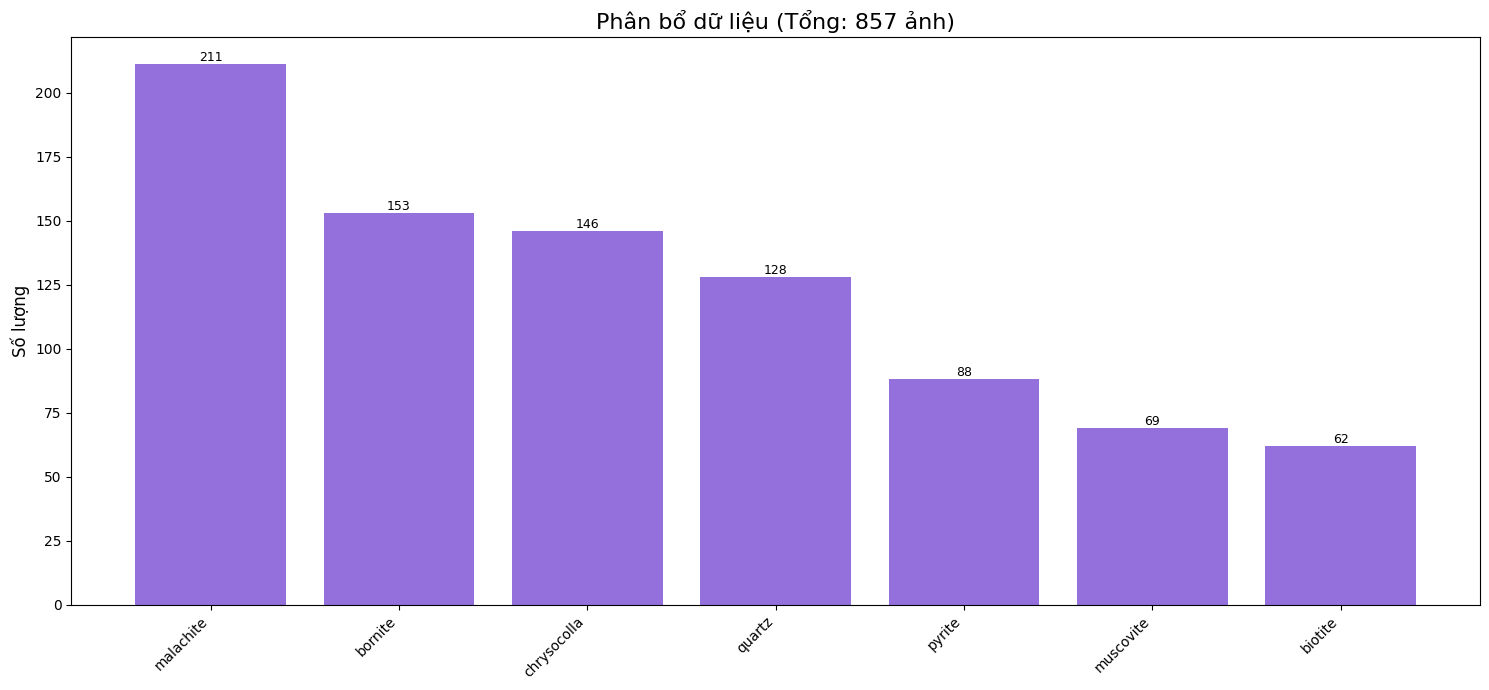


--- Phân bổ tập Validation ---


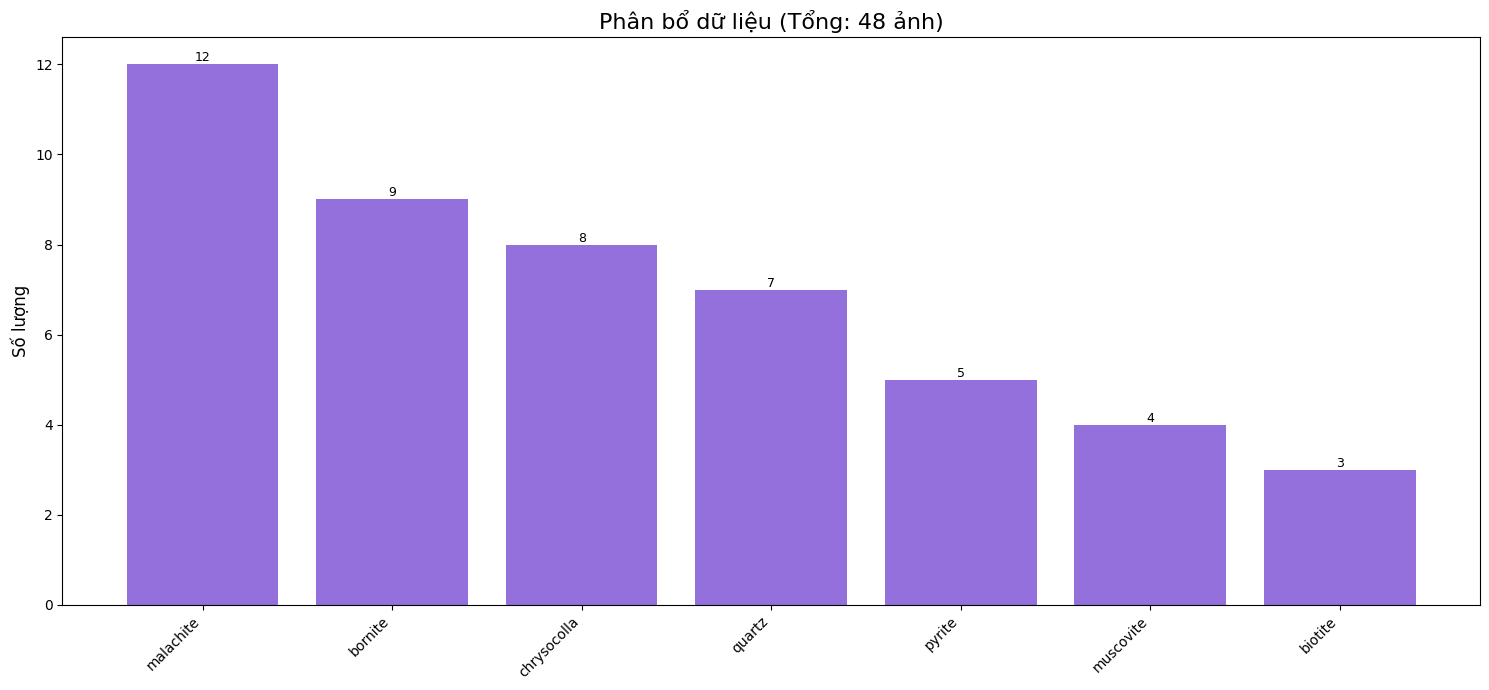


--- Phân bổ tập Test ---


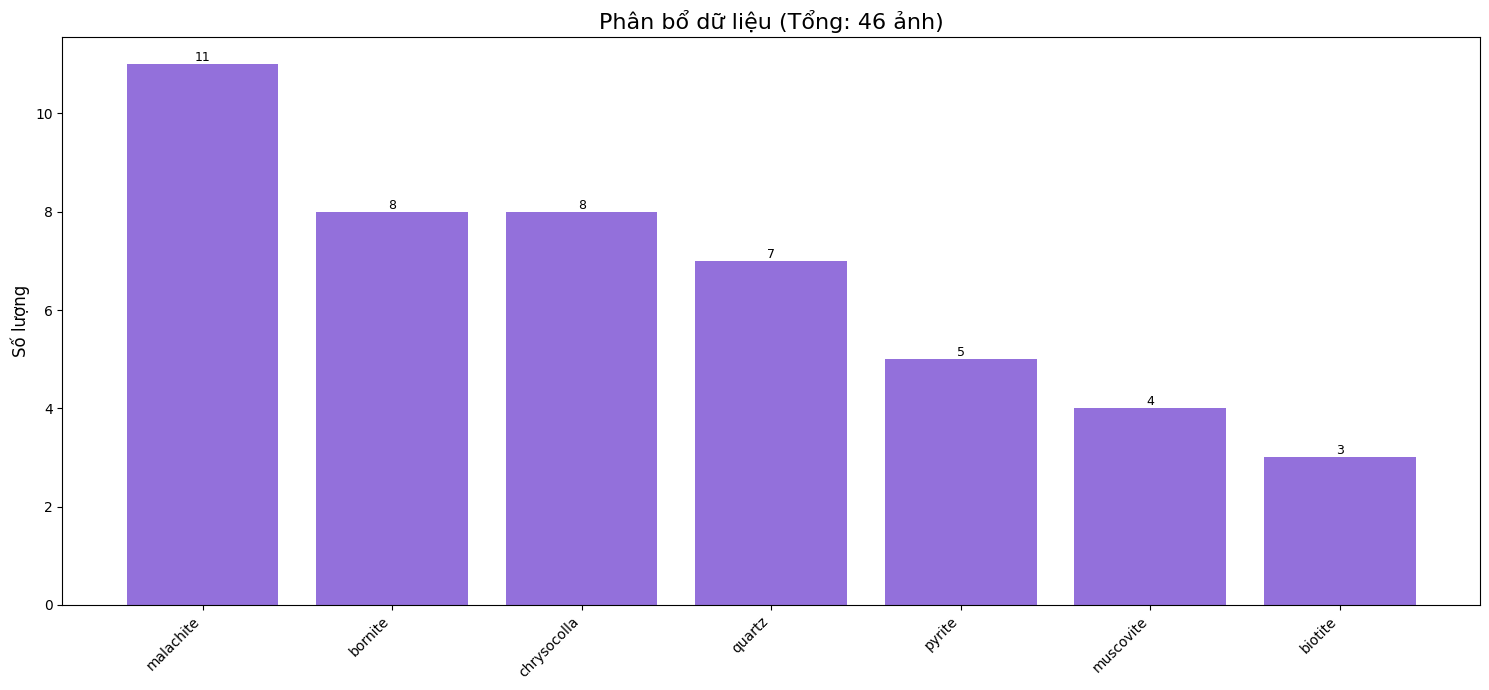

In [ ]:
dataset = ImageFolder(data_dir, transform=transforms.ToTensor())
print('Data size: ',len(dataset))

# Gán 'target_label' từ thuộc tính 'classes' của ImageFolder
# Đây là cách làm chuẩn, đảm bảo nhãn số và tên khớp nhau
target_label = dataset.classes
print(f"Các lớp (Classes): {target_label}")


def plot_dist(indexes, dataset=dataset):
    """
    Hàm vẽ biểu đồ phân bổ (không thay đổi)
    """
    count = Counter()
    for i in indexes:
        _, label = dataset[i] # Lấy nhãn từ dataset
        count[target_label[label]] += 1 # Đếm theo tên (ví dụ: 'Quartz')

    dist_2 = dict(sorted(count.items(), key=lambda kv: kv[1], reverse=True))

    plt.figure(figsize=(15, 7))
    bars = plt.bar(dist_2.keys(), dist_2.values(), color='mediumpurple')
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Phân bổ dữ liệu (Tổng: {len(indexes)} ảnh)', fontsize=16)
    plt.ylabel('Số lượng', fontsize=12)

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval),
                 ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

# --- BƯỚC 1: Tạo bản đồ {chỉ số: nhãn} ---
print("\n--- Đang tạo bản đồ chỉ số -> nhãn ---")
# Tối ưu hóa: Dùng 'dataset.samples' sẽ nhanh hơn nhiều
# vì nó không cần tải từng ảnh vào bộ nhớ
idx_label = {i: label for i, (path, label) in enumerate(dataset.samples)}
print(f"Đã tạo bản đồ cho {len(idx_label)} ảnh.")

# --- BƯỚC 2: Tách 5% làm tập Validation (val_keys) ---
# (Logic của bạn giữ nguyên, rất chính xác)
train_temp_keys, val_keys, _, _ = train_test_split(
    list(idx_label.keys()),
    list(idx_label.values()),
    stratify=list(idx_label.values()),
    test_size=0.05,
    random_state=42
)

# --- BƯỚC 3: Tạo bộ 95% còn lại (loại bỏ val_keys) ---
# (Logic của bạn giữ nguyên)
idx_label_2 = {}
for idx, label in idx_label.items():
    if idx not in val_keys:
        idx_label_2[idx] = label

# --- BƯỚC 4: Tách tập Train và Test từ 95% đó ---
# (Logic của bạn giữ nguyên)
train_keys, test_keys, _, _ = train_test_split(
    list(idx_label_2.keys()),
    list(idx_label_2.values()),
    stratify=list(idx_label_2.values()),
    test_size=0.05, # 5% của 95%
    random_state=42
)

# --- BƯỚC 5: In kết quả và Vẽ biểu đồ ---
print("\n--- KẾT QUẢ CHIA TẬP ---")
print(f"Số lượng tập Train: {len(train_keys)}")
print(f"Số lượng tập Validation: {len(val_keys)}")
print(f"Số lượng tập Test: {len(test_keys)}")
print("-" * 30)

# Vẽ 3 biểu đồ
print("\n--- Phân bổ tập Train ---")
plot_dist(train_keys)

print("\n--- Phân bổ tập Validation ---")
plot_dist(val_keys)

print("\n--- Phân bổ tập Test ---")
plot_dist(test_keys)

# **🚀 Mạng Nơ-ron Tích chập (CNN)**

## ✨ Data Augmentation

Vì tập data mà chúng tôi sử dụng có kích thước bé và để tránh trường hợp xảy ra Overfit, chúng tôi đã sử dụng **Tăng cường Dữ liệu (Data Augmentation)** với việc kỹ thuật áp dụng các phép biến đổi ngẫu nhiên (như lật, xoay, cắt).



In [ ]:
# 1. Dùng cho TẬP TRAIN (CÓ Data Augmentation)
# (Đây chính là 'data_transform' trong code của bạn)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(30),       # Ngẫu nhiên
    transforms.RandomVerticalFlip(p=0.5),  # Ngẫu nhiên
    transforms.RandomHorizontalFlip(p=0.5),# Ngẫu nhiên
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
load_data = ImageFolder(data_dir, transform=train_transform)

# 2. Dùng cho TẬP VALIDATION & TEST (KHÔNG có Augmentation)
# Chỉ Resize, ToTensor, Normalize
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    # KHÔNG CÓ RandomRotation
    # KHÔNG CÓ RandomVerticalFlip
    # KHÔNG CÓ RandomHorizontalFlip
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


## 📦 Quản Lý Tải Dữ Liệu Bằng DataLoader và Sampler

In [ ]:
#load into dataloader for each data after split it
batch_size = 128

#using subset to get data from indexes with the same distribution label
train_set = SubsetRandomSampler(train_keys)
val_set = SubsetRandomSampler(val_keys)
test_set = SubsetRandomSampler(test_keys)

#dataloader
train_loader = DataLoader(load_data, batch_size=batch_size,
                          shuffle=False, num_workers=4, sampler= train_set)
val_loader = DataLoader(load_data, batch_size=batch_size,
                        num_workers=4, sampler=val_set)
test_loader = DataLoader(load_data, batch_size=batch_size,
                         num_workers=4, sampler=test_set)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


##🚀 Tổng Quan Pipeline Huấn Luyện Mô Hình PyTorch


Ở đây, tôi thực hiện việc kiểm tra và lựa chọn GPU/CPU (device) để tối ưu tốc độ tính toán, sau đó định nghĩa kiến trúc mạng nơ-ron tích chập (Mineral_1) với 4 lớp tích chập và các lớp tuyến tính (nn.Linear) cuối cùng, và di chuyển mô hình lên thiết bị đã chọn.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")


# --- 2. Định nghĩa kiến trúc mô hình của bạn ---
# (Mã gốc của bạn là chính xác, không cần sửa đổi)
class Mineral_1(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # Giả định đầu vào là (B, 3, 224, 224)

            # Lớp 1: Input (3, 224, 224) -> Output (48, 70, 70)
            nn.Conv2d(3, 48, 11, stride=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(3, 1), # K(3,1) -> (72-3)/1+1 = 70

            # Lớp 2: Input (48, 70, 70) -> Output (128, 64, 64)
            nn.Conv2d(48, 128, 5, stride=1, padding=0), # (70-5)/1+1 = 66
            nn.ReLU(),
            nn.MaxPool2d(3, 1), # K(3,1) -> (66-3)/1+1 = 64

            # Lớp 3: Input (128, 64, 64) -> Output (128, 20, 20)
            nn.Conv2d(128, 128, 4, stride=1, padding=0), # (64-4)/1+1 = 61
            nn.ReLU(),
            nn.MaxPool2d(4, 3), # K(4,3) -> (61-4)/3+1 = 20

            # Lớp 4: Input (128, 20, 20) -> Output (64, 6, 6)
            nn.Conv2d(128, 64, 3, stride=1, padding=0), # (20-3)/1+1 = 18
            nn.ReLU(),
            nn.MaxPool2d(3, 3), # K(3,3) -> (18-3)/3+1 = 6

            # Lớp 5: Phần Phân loại (Flatten & Linear)
            nn.Flatten(),
            nn.Linear(64*6*6, 512), # 64*6*6 = 2304
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(512, 7),     # 7 Lớp đầu ra (ứng với 7 loại khoáng sản)
            nn.LogSoftmax(dim=1),
            )

    def forward(self, x):
        out = self.net(x)
        return out

# --- 3. Khởi tạo và di chuyển mô hình lên GPU (nếu có) ---
model_1 = Mineral_1()
model_1.to(device) # <-- Rất quan trọng

# 4. In ra cấu trúc mô hình
print("\n--- Cấu trúc mô hình Mineral_1 ---")
print(model_1)

Đang sử dụng thiết bị: cuda

--- Cấu trúc mô hình Mineral_1 ---
Mineral_1(
  (net): Sequential(
    (0): Conv2d(3, 48, kernel_size=(11, 11), stride=(3, 3))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=3, stride=1, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(48, 128, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=3, stride=1, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 128, kernel_size=(4, 4), stride=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=4, stride=3, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
    (12): Flatten(start_dim=1, end_dim=-1)
    (13): Linear(in_features=2304, out_features=512, bias=True)
    (14): ReLU()
    (15): Dropout(p=0.3, inplace=False)
    (16): Linear(in_features=512, out_features=7, bias=True)
    (17): LogSoftmax(dim=1)
  )
)


Hàm này quản lý toàn bộ vòng lặp huấn luyện, bao gồm việc thực hiện Forward và Backward Pass để cập nhật trọng số trên tập huấn luyện, sau đó đánh giá hiệu suất mô hình một cách an toàn trên tập kiểm thực bằng torch.no_grad() sau mỗi epoch.

In [ ]:
def fit(epochs, model, train_loader, val_loader, criterion, optimizer):
    """
    Hàm huấn luyện và kiểm thực mô hình PyTorch.
    """
    train_losses = []
    test_losses = []
    train_accu = []
    val_accu = []
    fit_time = time.time()

    print(f"--- Bắt đầu huấn luyện với {epochs} epochs ---")

    for e in range(epochs):
        since = time.time()
        running_loss = 0
        train_acc = 0

        # --- PHA HUẤN LUYỆN ---
        model.train() # Đặt mô hình ở chế độ training (bật Dropout,...)
        for image, label in train_loader:
            optimizer.zero_grad()
            image = image.to(device); label = label.to(device);

            # 1. Forward pass (Đưa ảnh qua mô hình)
            output = model(image)

            # 2. Tính Accuracy
            ps = torch.exp(output) # Lấy xác suất (vì model dùng LogSoftmax)
            _, top_class = ps.topk(1, dim=1)
            correct = top_class == label.view(*top_class.shape)
            train_acc += torch.mean(correct.type(torch.FloatTensor))

            # 3. Tính Loss và Backward pass (học)
            loss = criterion(output, label)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # --- PHA KIỂM THỰC (VALIDATION) ---
        else: # Khối này chạy sau khi vòng lặp 'train_loader' kết thúc
            model.eval() # Đặt mô hình ở chế độ evaluation (tắt Dropout,...)
            test_loss = 0
            accuracy = 0

            # Tắt tính toán gradient để tiết kiệm bộ nhớ và tăng tốc
            with torch.no_grad():
                for image, label in val_loader:
                    image = image.to(device); label = label.to(device);

                    # 1. Forward pass
                    output = model(image)
                    loss = criterion(output, label)

                    # 2. Tính Accuracy
                    ps = torch.exp(output)
                    _, top_class = ps.topk(1, dim=1)
                    correct = top_class == label.view(*top_class.shape)
                    accuracy += torch.mean(correct.type(torch.FloatTensor))

                    test_loss += loss.item()

            # --- Ghi lại kết quả của Epoch ---
            train_losses.append(running_loss/len(train_loader))
            test_losses.append(test_loss/len(val_loader))
            train_accu.append(train_acc/len(train_loader))
            val_accu.append(accuracy/len(val_loader))

            # Chuyển về chế độ train cho epoch tiếp theo
            model.train()

            print("Epoch: {}/{}.. ".format(e+1, epochs),
                  "Train Loss: {:.3f}.. ".format(running_loss/len(train_loader)),
                  "Test Loss: {:.3f}.. ".format(test_loss/len(val_loader)),
                  "Train Accuracy: {:.3f}.. ".format(train_acc/len(train_loader)),
                  "Test Accuracy: {:.3f}.. ".format(accuracy/len(val_loader)),
                  "Time: {:.2f}s" .format((time.time()-since)))

    history = {'train_loss' : train_losses, 'val_loss': test_losses,
               'train_accuracy': train_accu, 'val_accuracy':val_accu}
    print('Total time: {:.2f} m' .format((time.time()- fit_time)/60))
    return history

Hai hàm này chịu trách nhiệm cho việc lưu trữ và phục hồi trạng thái huấn luyện của mô hình, đảm bảo save_model chỉ lưu state_dict (trọng số và optimizer) và load_model có thể tải trọng số vào một kiến trúc mới, đặt mô hình ở chế độ Huấn luyện (Train) hoặc Dự đoán (Inference).

In [ ]:
def save_model(model, optimizer, fpath):
    """
    Lưu checkpoint của mô hình.
    Chỉ lưu 'state_dict' (trọng số) thay vì lưu cả đối tượng model.
    """
    print(f"--- Đang lưu checkpoint tại: {fpath} ---")

    # Tạo checkpoint chỉ chứa các 'state_dict' (trạng thái)
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }

    # Lưu checkpoint vào file
    torch.save(checkpoint, fpath)
    print("Đã lưu thành công.")


def load_model(fpath, model_architecture, optimizer_to_load=None, device='cpu', inference=True):
    """
    Tải checkpoint (trọng số) vào một kiến trúc mô hình đã được khởi tạo.

    Args:
        fpath (str): Đường dẫn đến file checkpoint (.pth).
        model_architecture (nn.Module): MỘT MÔ HÌNH MỚI đã được khởi tạo.
                                        (Ví dụ: Mineral_1())
        optimizer_to_load (optim): Optimizer đã khởi tạo (nếu muốn tiếp tục train).
        device (torch.device): Thiết bị (device) để tải mô hình lên.
        inference (bool):
            - True: (Mặc định) Để dự đoán (model.eval(), no_grad=True).
            - False: Để tiếp tục huấn luyện (model.train()).

    Returns:
        (model, optimizer) đã được tải trọng số.
    """
    try:
        print(f"--- Đang tải checkpoint từ: {fpath} ---")

        # Tải checkpoint, map_location=device xử lý việc tải mô hình
        # từ GPU -> CPU hoặc CPU -> GPU một cách mượt mà.
        checkpoint = torch.load(fpath, map_location=device)

        # Tải trọng số (weights) vào kiến trúc mô hình
        model_architecture.load_state_dict(checkpoint['model_state_dict'])

        # Di chuyển mô hình đến đúng thiết bị (GPU/CPU)
        model_architecture.to(device)
        print("Đã tải 'model_state_dict' thành công.")

        # Tải trạng thái của Optimizer (nếu có)
        if optimizer_to_load and 'optimizer_state_dict' in checkpoint and not inference:
            optimizer_to_load.load_state_dict(checkpoint['optimizer_state_dict'])
            print("Đã tải 'optimizer_state_dict' thành công.")

        # Cài đặt chế độ cho mô hình
        if inference:
            print("Cài đặt mô hình sang chế độ Dự đoán (Inference).")
            model_architecture.eval()
            for param in model_architecture.parameters():
                param.requires_grad = False
        else:
            print("Cài đặt mô hình sang chế độ Huấn luyện (Train).")
            model_architecture.train()

        return model_architecture, optimizer_to_load

    except FileNotFoundError:
        print(f"LỖI: Không tìm thấy file checkpoint tại {fpath}")
        return None, None
    except Exception as e:
        print(f"LỖI: Đã xảy ra lỗi khi tải checkpoint: {e}")
        return None, None

Khối lệnh này thiết lập các thành phần cốt lõi của quá trình huấn luyện: chọn Hàm Mất Mát (nn.NLLLoss) và Trình Tối ưu hóa (optim.Adam với lr đã định), sau đó gọi hàm fit để thực thi huấn luyện mô hình qua số lượng epochs đã chỉ định, và cuối cùng lưu lại trọng số mô hình đã được huấn luyện.

In [ ]:
print("--- KHỞI TẠO CÁC THÀNH PHẦN HUẤN LUYỆN ---")

# 1. Chọn Hàm Mất Mát (Criterion)
# Dùng NLLLoss vì model_1 của bạn đã kết thúc bằng LogSoftmax
criterion = nn.NLLLoss()

# 2. Chọn Trình Tối ưu hóa (Optimizer)
# Sử dụng lr=0.0001 là một lựa chọn tốt để bắt đầu
optimizer = optim.Adam(model_1.parameters(), lr=0.0001)

# 3. Số lượng Epochs
EPOCHS = 30 # Đổi tên từ 'epoch' để tránh nhầm lẫn

# 4. Gọi hàm 'fit' để huấn luyện
# (Đây là nơi quá trình huấn luyện diễn ra và sẽ mất nhiều thời gian)
history_mineral = fit(EPOCHS, model_1, train_loader, val_loader, criterion, optimizer)

# 5. Lưu mô hình sau khi huấn luyện xong
print("\n--- Huấn luyện hoàn tất. Đang lưu mô hình... ---")
save_model(model_1, optimizer, 'mineral_model_final.pth') # Đổi tên file
print("Đã lưu mô hình tại 'mineral_model_final.pth'")

--- KHỞI TẠO CÁC THÀNH PHẦN HUẤN LUYỆN ---
--- Bắt đầu huấn luyện với 30 epochs ---
Epoch: 1/30..  Train Loss: 1.896..  Test Loss: 1.851..  Train Accuracy: 0.223..  Test Accuracy: 0.250..  Time: 15.01s
Epoch: 2/30..  Train Loss: 1.759..  Test Loss: 1.678..  Train Accuracy: 0.300..  Test Accuracy: 0.396..  Time: 14.39s
Epoch: 3/30..  Train Loss: 1.561..  Test Loss: 1.445..  Train Accuracy: 0.392..  Test Accuracy: 0.521..  Time: 14.50s
Epoch: 4/30..  Train Loss: 1.346..  Test Loss: 1.371..  Train Accuracy: 0.443..  Test Accuracy: 0.417..  Time: 14.68s
Epoch: 5/30..  Train Loss: 1.211..  Test Loss: 1.117..  Train Accuracy: 0.535..  Test Accuracy: 0.521..  Time: 14.47s
Epoch: 6/30..  Train Loss: 1.137..  Test Loss: 1.074..  Train Accuracy: 0.563..  Test Accuracy: 0.604..  Time: 15.54s
Epoch: 7/30..  Train Loss: 1.030..  Test Loss: 0.994..  Train Accuracy: 0.616..  Test Accuracy: 0.625..  Time: 14.20s
Epoch: 8/30..  Train Loss: 0.951..  Test Loss: 1.040..  Train Accuracy: 0.653..  Test Accu

Vẽ biểu đồ biểu đồ hiển thị Loss và Accuracy của cả tập Train và Validation qua các Epoch


--- Đang vẽ biểu đồ Loss và Accuracy ---


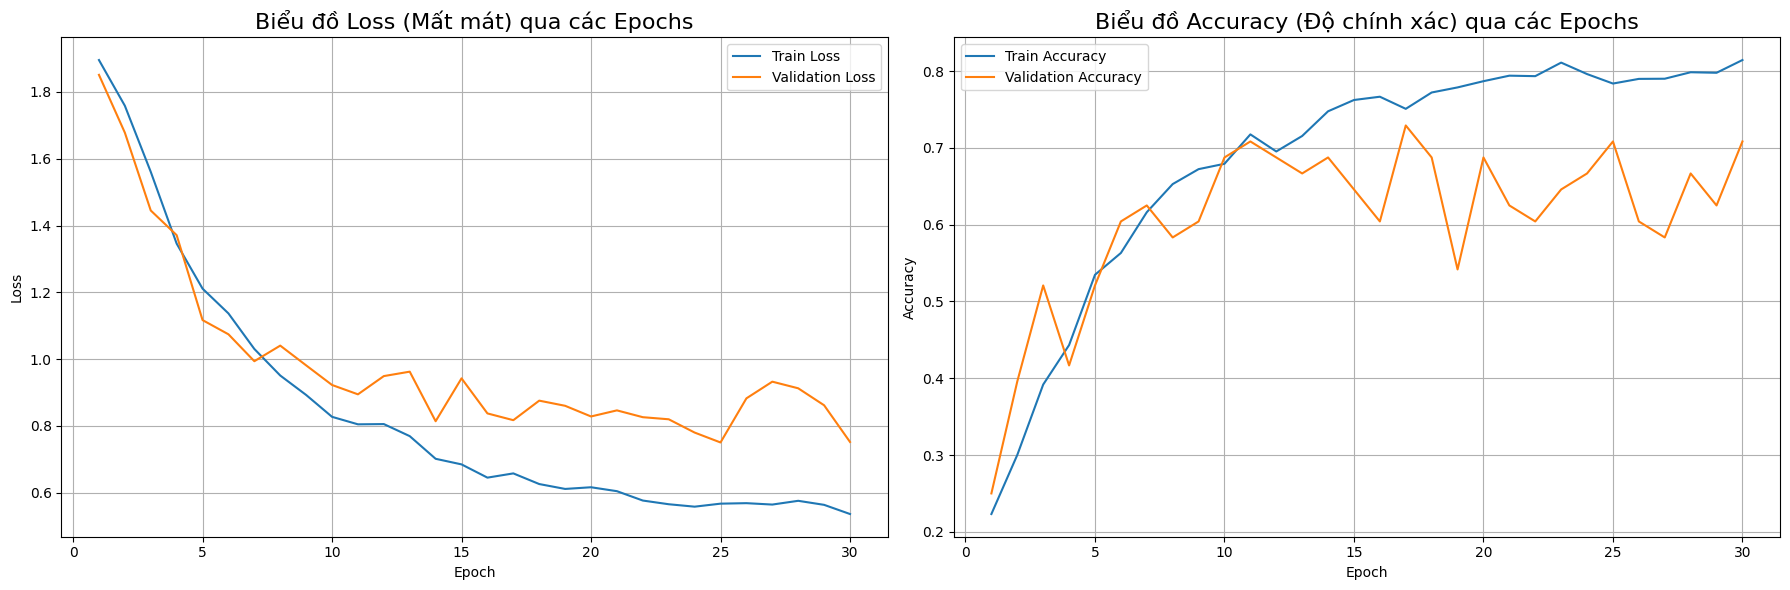

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, n_epoch):
    """
    Vẽ biểu đồ Loss và Accuracy từ history (ĐÃ SỬA LỖI TENSOR).
    """

    # Tạo danh sách các epoch (ví dụ: [1, 2, ..., 40])
    epochs_list = list(range(1, n_epoch + 1))

    # --- SỬA LỖI TẠI ĐÂY ---
    # Chuyển Accuracy Tensors (trên GPU/CPU) sang CPU và Numpy
    # (Loss đã là float, không cần chuyển)

    try:
        train_accu_np = [a.cpu().numpy() if isinstance(a, torch.Tensor) else a for a in history['train_accuracy']]
        val_accu_np = [a.cpu().numpy() if isinstance(a, torch.Tensor) else a for a in history['val_accuracy']]
    except Exception as e:
        print(f"Lỗi khi chuyển đổi accuracy: {e}")
        print("Đảm bảo history['train_accuracy'] chứa danh sách các tensor hoặc số.")
        return

    # Tạo 2 biểu đồ con (sub-plots) trên cùng 1 hàng
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # --- Biểu đồ 1: Loss ---
    ax1.plot(epochs_list, history['train_loss'], label='Train Loss')
    ax1.plot(epochs_list, history['val_loss'], label='Validation Loss')
    ax1.set_title('Biểu đồ Loss (Mất mát) qua các Epochs', fontsize=16)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True) # Thêm lưới

    # --- Biểu đồ 2: Accuracy ---
    ax2.plot(epochs_list, train_accu_np, label='Train Accuracy')
    ax2.plot(epochs_list, val_accu_np, label='Validation Accuracy')
    ax2.set_title('Biểu đồ Accuracy (Độ chính xác) qua các Epochs', fontsize=16)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True) # Thêm lưới

    plt.tight_layout()
    plt.show()

# --- Gọi hàm vẽ biểu đồ ---
print("\n--- Đang vẽ biểu đồ Loss và Accuracy ---")
plot_history(history_mineral, EPOCHS)


#📚 So sánh kết quả với EfficientNet-B0

###✨ Phần 1: Chuẩn bị và Cân bằng Dữ liệu

Để chuẩn bị dữ liệu cho mô hình EfficientNet, chúng tôi định nghĩa ba quy trình biến đổi (`transforms`) cho các tập huấn luyện, kiểm định và kiểm thử.

* Tất cả các tập đều được chuẩn hóa kích thước (`Resize`), chuyển sang 3 kênh màu (`RGB`), đổi thành `Tensor`, và **chuẩn hóa (Normalize)** bằng trung bình/độ lệch chuẩn của ImageNet, điều bắt buộc khi sửu dụng mô hình tiền huấn luyện.
* Riêng tập huấn luyện (`train_transforms`) được áp dụng thêm các kỹ thuật **tăng cường dữ liệu** (data augmentation) như `RandomHorizontalFlip`, `RandomRotation`, và `RandomErasing` để tăng tính đa dạng và giảm overfitting.

Một thách thức lớn của bộ dữ liệu là **mất cân bằng lớp**. Chúng tôi giải quyết vấn đề này bằng cách sửSử dụng `WeightedRandomSampler` cho `train_loader`. Bộ lấy mẫu này tính toán trọng số dựa trên nghịch đảo tần suất của mỗi lớp, sau đó lấy mẫu từ tập huấn luyện sao cho các lớp hiếm (thiểu số) xuất hiện thường xuyên hơn trong mỗi batch. Các `DataLoader` cho tập kiểm định và kiểm thử vẫn sử dụng phương pháp lấy mẫu tiêu chuẩn.

In [ ]:
# --- 1. ĐỊNH NGHĨA CÁC PHÉP BIẾN ĐỔI (Transforms) ---

train_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.Lambda(lambda x: x.convert('RGB')),

    # --- THÊM AUGMENTATION ---
    transforms.RandomHorizontalFlip(p=0.5), # Lật ngang ngẫu nhiên
    transforms.RandomRotation(30), # Xoay ngẫu nhiên
    #transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Thay đổi màu sắc
    # -------------------------

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3))
    # Thêm Normalization nếu bạn biết mean/std của ImageNet
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.Lambda(lambda x: x.convert('RGB')),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
test_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.Lambda(lambda x: x.convert('RGB')),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# --- 2. TẠO DATASET ---

train_data = ImageFolder(data_dir, transform=train_transforms)
val_data = ImageFolder(data_dir, transform=val_transforms)
test_data = ImageFolder(data_dir, transform=test_transforms)


# ======================================================================
# --- 3. (THAY ĐỔI) XỬ LÝ MẤT CÂN BẰNG CHO TẬP TRAIN ---
# Chúng ta sẽ thay thế train_sampler bằng WeightedRandomSampler

# 3.1. Lấy nhãn của chỉ tập train (train_keys từ ô 9)
train_labels = [idx_label[i] for i in train_keys]
num_classes = len(dataset.classes) # 7 lớp

# 3.2. Đếm số lượng mẫu mỗi lớp TRONG TẬP TRAIN
class_counts = Counter(train_labels)
print(f"Số lượng mẫu train theo lớp (trước khi cân bằng): {class_counts}")

# 3.3. Tính trọng số (weight) cho từng LỚP (lớp nào ít mẫu, trọng số cao)
# Sắp xếp lại class_counts theo đúng thứ tự 0 (biotite), 1 (bornite), ...
class_counts_sorted = [class_counts[i] for i in range(num_classes)]
class_weights = [1.0 / count for count in class_counts_sorted]
print(f"Trọng số (weights) cho 7 lớp: {class_weights}")

# 3.4. Tạo trọng số cho TỪNG MẪU (sample) trong tập train (sẽ có 862 trọng số)
sample_weights = [class_weights[label] for label in train_labels]

# 3.5. Tạo WeightedRandomSampler
train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True # Lấy mẫu có thay thế
)

# (Samplers cho Val và Test giữ nguyên SubsetRandomSampler)
val_sampler = SubsetRandomSampler(val_keys)
test_sampler = SubsetRandomSampler(test_keys)

# ======================================================================

# --- 4. TẠO DATALOADERS ---
BATCH_SIZE = 32
# (train_loader bây giờ đã dùng sampler đã được cân bằng)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, sampler=train_sampler)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, sampler=val_sampler)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, sampler=test_sampler)

print("\\n--- DataLoaders đã sẵn sàng (đã cân bằng tập Train) ---")

Số lượng mẫu train theo lớp (trước khi cân bằng): Counter({3: 211, 1: 153, 2: 146, 6: 128, 5: 88, 4: 69, 0: 62})
Trọng số (weights) cho 7 lớp: [0.016129032258064516, 0.006535947712418301, 0.00684931506849315, 0.004739336492890996, 0.014492753623188406, 0.011363636363636364, 0.0078125]
\n--- DataLoaders đã sẵn sàng (đã cân bằng tập Train) ---


In [ ]:
#load into dataloader for each data after split it
batch_size = 128

#using subset to get data from indexes with the same distribution label
train_set = SubsetRandomSampler(train_keys)
val_set = SubsetRandomSampler(val_keys)
test_set = SubsetRandomSampler(test_keys)

load_data = ImageFolder(data_dir, transform=train_transforms)

#dataloader
train_loader = DataLoader(load_data, batch_size=batch_size,
                          shuffle=False, num_workers=4, sampler= train_set)
val_loader = DataLoader(load_data, batch_size=batch_size,
                        num_workers=4, sampler=val_set)
test_loader = DataLoader(load_data, batch_size=batch_size,
                         num_workers=4, sampler=test_set)

###✨ Phần 2: Thiết lập Mô hình (Model Setup - Transfer Learning)

Trong đoạn mã này, chúng tôi thiết lập mô hình EfficientNet-B0 bằng kỹ thuật **Transfer Learning** (Học chuyển giao).

1.  Tải mô hình `efficientnet_b0` đã được tiền huấn luyện (pre-trained) trên tập dữ liệu ImageNet.
2.  **"Đóng băng" (freeze)** toàn bộ các lớp của mô hình. Bằng cách thiết lập `param.requires_grad = False`, chúng tôi đảm bảo các trọng số đã được huấn luyện trước sẽ không bị thay đổi.
3.  **Thay thế lớp phân loại (classifier):** Lớp `classifier` gốc của EfficientNet (có 1000 đầu ra cho ImageNet) được gỡ bỏ. Chúng tôi thay thế nó bằng một khối `nn.Sequential` mới, bao gồm một lớp `Dropout` (để chống quá khớp) và một lớp `nn.Linear` mới chỉ có **7 đầu ra**, tương ứng với 7 lớp khoáng thạch trong bộ dữ liệu của chúng ta.
4.  Cuối cùng, mô hình đã được sửa đổi (`model_1`) được chuyển sang `device` (ưu tiên GPU/CUDA nếu có) để chuẩn bị cho quá trình huấn luyện.

In [ ]:
print("--- Tải mô hình EfficientNet-B0 (PyTorch) ---")

# 1. Tải mô hình EfficientNet-B0 đã được huấn luyện trước trên ImageNet
base_model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

# 2. "Đóng băng" (freeze) tất cả các trọng số của mô hình gốc
# Chúng ta không muốn huấn luyện lại các lớp đã học, chỉ huấn luyện lớp cuối
for param in base_model.parameters():
    param.requires_grad = False

# 3. Thay thế lớp phân loại (classifier) cuối cùng
# Lớp classifier gốc của EfficientNet-B0 có 1000 đầu ra (cho ImageNet)
# Chúng ta cần 7 đầu ra (cho 7 lớp khoáng thạch)

# Lấy số lượng features đầu vào của lớp classifier (là 1280)
num_features = base_model.classifier[1].in_features

# Định nghĩa lại lớp classifier
base_model.classifier = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True), # Giữ lại Dropout
    nn.Linear(num_features, 7)       # Lớp Linear mới với 7 đầu ra
)

# 4. Gán mô hình mới này cho biến model_1
model_1 = base_model # Ghi đè biến model_1 cũ

# Chuyển mô hình sang GPU (nếu có)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")

# In ra cấu trúc classifier mới để kiểm tra
print("\n--- Cấu trúc classifier MỚI của model_1 ---")
print(model_1.classifier)

print("\n--- Model_1 đã được thay thế bằng EfficientNetB0 (PyTorch) ---")

--- Tải mô hình EfficientNet-B0 (PyTorch) ---
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 155MB/s]

Đang sử dụng thiết bị: cuda

--- Cấu trúc classifier MỚI của model_1 ---
Sequential(
  (0): Dropout(p=0.4, inplace=True)
  (1): Linear(in_features=1280, out_features=7, bias=True)
)

--- Model_1 đã được thay thế bằng EfficientNetB0 (PyTorch) ---


###✨ Phần 3: Hàm Huấn luyện (Training Loop) với Early Stopping

Đây là hàm `fit`, đóng vai trò là vòng lặp huấn luyện và đánh giá chính của mô hình.

Hàm này thực hiện các chức năng then chốt sau:

* **Vòng lặp Train/Val:** Trong mỗi epoch, hàm thực hiện một vòng lặp huấn luyện (`model.train()`) trên `train_loader` để tính toán loss, lan truyền ngược (backward) và cập nhật trọng số (`optimizer.step()`). Ngay sau đó, nó chuyển sang chế độ đánh giá (`model.eval()`) và chạy một vòng lặp kiểm định trên `val_loader` để đo lường hiệu suất trên dữ liệu mô hình chưa thấy.

* **Lưu mô hình tốt nhất (Checkpointing):** Hàm liên tục theo dõi giá trị validation loss (`val_loss`). Nếu `val_loss` của epoch hiện tại thấp hơn giá trị `best_val_loss` (loss tốt nhất từ trước đến nay), mô hình sẽ ngay lập tức được lưu vào tệp (`model_save_path`). Điều này đảm bảo chúng ta luôn giữ lại phiên bản mô hình có hiệu suất cao nhất.

* **Dừng sớm (Early Stopping):** Hàm cũng triển khai cơ chế "kiên nhẫn" (`patience`). Nếu `val_loss` không được cải thiện (không giảm) trong một số epoch liên tiếp (bằng `patience`), quá trình huấn luyện sẽ tự động dừng (`break`). Kỹ thuật này giúp ngăn chặn overfitting và tiết kiệm thời gian huấn luyện khi mô hình không còn học được thêm.

* **Điều chỉnh Learning Rate (Scheduler):** Hàm có thể nhận một `scheduler` (ví dụ: `ReduceLROnPlateau`). Nếu có, `scheduler.step(val_loss)` sẽ được gọi sau mỗi epoch, cho phép tự động điều chỉnh learning rate dựa trên sự cải thiện của validation loss.



In [ ]:
def fit(epochs, model, train_loader, val_loader, criterion, optimizer, scheduler=None, patience=5,model_save_path="best_model.pth"): # <-- 1. THÊM scheduler=None

    print(f"--- Bắt đầu huấn luyện với {epochs} epochs ---")

    # Chuẩn bị lưu trữ history
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    # --- 3. KHỞI TẠO BIẾN CHO EARLY STOPPING ---
    best_val_loss = np.inf # Đặt loss tốt nhất là vô cực
    patience_counter = 0   # Bộ đếm kiên nhẫn

    # Chuyển model sang thiết bị (GPU nếu có)
    model.to(device)

    for epoch in range(epochs):
        train_loss = 0.0
        val_loss = 0.0
        train_correct = 0
        train_total = 0
        val_correct = 0
        val_total = 0

        # --- 1. Vòng lặp HUẤN LUYỆN (Training) ---
        model.train()
        for i, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        # --- 2. Vòng lặp ĐÁNH GIÁ (Validation) ---
        model.eval()
        with torch.no_grad():
            for i, (images, labels) in enumerate(val_loader):
                images = images.to(device)
                labels = labels.to(device)

                output = model(images)
                loss = criterion(output, labels)

                val_loss += loss.item()
                _, predicted = torch.max(output.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        # --- 3. Tính toán và lưu trữ kết quả ---
        train_loss = train_loss / len(train_loader)
        val_loss = val_loss / len(val_loader)
        train_acc = 100 * train_correct / train_total
        val_acc = 100 * val_correct / val_total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)


        if scheduler:
            # Chế độ 'min' (của ReduceLROnPlateau) sẽ theo dõi val_loss
            scheduler.step(val_loss)


        # ======================================================
        # --- 2. (ĐÂY LÀ PHẦN THÊM VÀO) ---
        # Gọi scheduler (nếu có)
        if scheduler:
            # Chế độ 'min' (của ReduceLROnPlateau) sẽ theo dõi val_loss
            scheduler.step(val_loss)
        # ======================================================

        print(f"Epoch {epoch+1}/{epochs} \t"
              f"Train Loss: {train_loss:.4f} \t Train Acc: {train_acc:.2f}% \t"
              f"Val Loss: {val_loss:.4f} \t Val Acc: {val_acc:.2f}%")
        if val_loss < best_val_loss:
                    # Tốt! Loss đã giảm. Lưu mô hình và reset bộ đếm.
                    print(f"  Validation loss giảm ({best_val_loss:.4f} --> {val_loss:.4f}). Đang lưu mô hình...")
                    torch.save(model.state_dict(), model_save_path)
                    best_val_loss = val_loss
                    patience_counter = 0
        else:
            # Không tốt! Loss không giảm. Tăng bộ đếm kiên nhẫn.
            patience_counter += 1
            print(f"  Validation loss không cải thiện. Đếm kiên nhẫn: {patience_counter}/{patience}")

        # Kiểm tra xem có nên dừng sớm không
        if patience_counter >= patience:
            print(f"!!! Dừng sớm (Early Stopping) tại epoch {epoch+1} !!!")
            break # Thoát khỏi vòng lặp train
    history = {
        'train_loss': train_losses,
        'val_loss': val_losses,
        'train_acc': train_accuracies,
        'val_acc': val_accuracies
    }

    return history


###✨ Phần 4: Hàm Lưu và Tải Checkpoint

Đoạn mã này định nghĩa hai hàm tiện ích (`save_model` và `load_model`) để quản lý "checkpoint" (trạng thái) của mô hình. Đây là một thực hành tốt nhất trong PyTorch, giúp lưu và tải trọng số một cách linh hoạt.

* **`save_model(model, optimizer, fpath)`**:
    * Hàm này không lưu *toàn bộ* đối tượng mô hình, mà chỉ lưu `state_dict` (bản đồ trạng thái/trọng số) của cả `model` và `optimizer`.
    * Việc này giúp file lưu trữ nhẹ hơn và linh hoạt hơn, có thể được tải trên các cấu trúc dự án khác nhau.

* **`load_model(fpath, model_architecture, ...)`**:
    * Hàm này dùng để tải các trọng số đã lưu (`fpath`) vào một kiến trúc mô hình **mới** được khởi tạo (`model_architecture`).
    * Nó sử dụng `map_location=device` để đảm bảo có thể tải checkpoint một cách mượt mà giữa các thiết bị (ví dụ: tải mô hình đã train trên GPU về CPU).
    * Hàm có tham số `inference` (mặc định là `True`):
        * Nếu `True`: Mô hình sẽ được đặt ở chế độ `eval()` và đóng băng gradient, sẵn sàng cho việc dự đoán.
        * Nếu `False`: Mô hình được đặt ở chế... độ `train()` và tùy chọn tải trạng thái của `optimizer`, sẵn sàng để tiếp tục (resume) quá trình huấn luyện.

In [ ]:
def save_model(model, optimizer, fpath):
    """
    Lưu checkpoint của mô hình.
    Chỉ lưu 'state_dict' (trọng số) thay vì lưu cả đối tượng model.
    """
    print(f"--- Đang lưu checkpoint tại: {fpath} ---")

    # Tạo checkpoint chỉ chứa các 'state_dict' (trạng thái)
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }

    # Lưu checkpoint vào file
    torch.save(checkpoint, fpath)
    print("Đã lưu thành công.")


def load_model(fpath, model_architecture, optimizer_to_load=None, device='cpu', inference=True):
    """
    Tải checkpoint (trọng số) vào một kiến trúc mô hình đã được khởi tạo.

    Args:
        fpath (str): Đường dẫn đến file checkpoint (.pth).
        model_architecture (nn.Module): MỘT MÔ HÌNH MỚI đã được khởi tạo.
                                        (Ví dụ: Mineral_1())
        optimizer_to_load (optim): Optimizer đã khởi tạo (nếu muốn tiếp tục train).
        device (torch.device): Thiết bị (device) để tải mô hình lên.
        inference (bool):
            - True: (Mặc định) Để dự đoán (model.eval(), no_grad=True).
            - False: Để tiếp tục huấn luyện (model.train()).

    Returns:
        (model, optimizer) đã được tải trọng số.
    """
    try:
        print(f"--- Đang tải checkpoint từ: {fpath} ---")

        # Tải checkpoint, map_location=device xử lý việc tải mô hình
        # từ GPU -> CPU hoặc CPU -> GPU một cách mượt mà.
        checkpoint = torch.load(fpath, map_location=device)

        # Tải trọng số (weights) vào kiến trúc mô hình
        model_architecture.load_state_dict(checkpoint['model_state_dict'])

        # Di chuyển mô hình đến đúng thiết bị (GPU/CPU)
        model_architecture.to(device)
        print("Đã tải 'model_state_dict' thành công.")

        # Tải trạng thái của Optimizer (nếu có)
        if optimizer_to_load and 'optimizer_state_dict' in checkpoint and not inference:
            optimizer_to_load.load_state_dict(checkpoint['optimizer_state_dict'])
            print("Đã tải 'optimizer_state_dict' thành công.")

        # Cài đặt chế độ cho mô hình
        if inference:
            print("Cài đặt mô hình sang chế độ Dự đoán (Inference).")
            model_architecture.eval()
            for param in model_architecture.parameters():
                param.requires_grad = False
        else:
            print("Cài đặt mô hình sang chế độ Huấn luyện (Train).")
            model_architecture.train()

        return model_architecture, optimizer_to_load

    except FileNotFoundError:
        print(f"LỖI: Không tìm thấy file checkpoint tại {fpath}")
        return None, None
    except Exception as e:
        print(f"LỖI: Đã xảy ra lỗi khi tải checkpoint: {e}")
        return None, None

###✨ Phần 5: Cấu hình và Chạy Huấn luyện

Đây là đoạn mã cuối cùng để khởi tạo các thành phần và thực thi vòng lặp huấn luyện.

1.  **Hàm Mất Mát (Criterion):** Chúng tôi sử dụng `CrossEntropyLoss` với `label_smoothing=0.1`. Label smoothing là một kỹ thuật regularization giúp mô hình bớt "tự tin" thái quá và tăng khả năng tổng quát hóa.

2.  **Trình Tối ưu hóa (Optimizer):** Chúng tôi chọn `Adam`. Một điểm mấu chốt ở đây là chúng tôi **chỉ truyền `model_1.classifier.parameters()`** cho optimizer, chứ không phải toàn bộ `model_1.parameters()`. Điều này có nghĩa là chỉ có các trọng số của lớp "đầu" (head) classifier mới mà chúng ta đã thêm vào được huấn luyện, trong khi toàn bộ phần thân (base) của EfficientNet vẫn được đóng băng.

3.  **Thực thi Huấn luyện:** Quá trình huấn luyện được bắt đầu bằng cách gọi hàm `fit` với 20 `EPOCHS`. Hàm này sẽ chạy, hiển thị kết quả mỗi epoch, và tự động lưu lại mô hình tốt nhất (best_model.pth) nhờ cơ chế Early Stopping đã định nghĩa bên trong.

4.  **Lưu mô hình cuối cùng:** Sau khi vòng lặp `fit` hoàn tất (do chạy hết 20 epoch hoặc do dừng sớm), chúng tôi lưu lại trạng thái cuối cùng của mô hình vào tệp `mineral_model_final.pth` để có thể sử dụng sau này.

In [ ]:
print("--- KHỞI TẠO CÁC THÀNH PHẦN HUẤN LUYỆN ---")

# 1. Chọn Hàm Mất Mát (Criterion)
# Dùng NLLLoss vì model_1 của bạn đã kết thúc bằng LogSoftmax
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# 2. Chọn Trình Tối ưu hóa (Optimizer)
# Sử dụng lr=0.0001 là một lựa chọn tốt để bắt đầu
#optimizer = optim.Adam(model_1.parameters(), lr=0.0001)
optimizer = optim.Adam(model_1.classifier.parameters(), lr=0.001,weight_decay=1e-5)

# 3. Số lượng Epochs
EPOCHS = 20 # Đổi tên từ 'epoch' để tránh nhầm lẫn

# 4. Gọi hàm 'fit' để huấn luyện
# (Đây là nơi quá trình huấn luyện diễn ra và sẽ mất nhiều thời gian)
history_mineral = fit(EPOCHS, model_1, train_loader, val_loader, criterion, optimizer)

# 5. Lưu mô hình sau khi huấn luyện xong
print("\n--- Huấn luyện hoàn tất. Đang lưu mô hình... ---")
save_model(model_1, optimizer, 'mineral_model_final.pth') # Đổi tên file
print("Đã lưu mô hình tại 'mineral_model_final.pth'")




--- KHỞI TẠO CÁC THÀNH PHẦN HUẤN LUYỆN ---
--- Bắt đầu huấn luyện với 20 epochs ---
Epoch 1/20 	Train Loss: 1.8404 	 Train Acc: 28.24% 	Val Loss: 1.7166 	 Val Acc: 35.42%
  Validation loss giảm (inf --> 1.7166). Đang lưu mô hình...
Epoch 2/20 	Train Loss: 1.6173 	 Train Acc: 46.32% 	Val Loss: 1.5059 	 Val Acc: 52.08%
  Validation loss giảm (1.7166 --> 1.5059). Đang lưu mô hình...
Epoch 3/20 	Train Loss: 1.4084 	 Train Acc: 62.54% 	Val Loss: 1.3076 	 Val Acc: 72.92%
  Validation loss giảm (1.5059 --> 1.3076). Đang lưu mô hình...
Epoch 4/20 	Train Loss: 1.2775 	 Train Acc: 69.43% 	Val Loss: 1.3011 	 Val Acc: 68.75%
  Validation loss giảm (1.3076 --> 1.3011). Đang lưu mô hình...
Epoch 5/20 	Train Loss: 1.1897 	 Train Acc: 74.10% 	Val Loss: 1.1142 	 Val Acc: 81.25%
  Validation loss giảm (1.3011 --> 1.1142). Đang lưu mô hình...
Epoch 6/20 	Train Loss: 1.1087 	 Train Acc: 78.30% 	Val Loss: 1.1010 	 Val Acc: 72.92%
  Validation loss giảm (1.1142 --> 1.1010). Đang lưu mô hình...
Epoch 7/20 	T


--- Đang vẽ biểu đồ Loss và Accuracy ---

Đã lưu biểu đồ vào file 'training_history_plot.png'


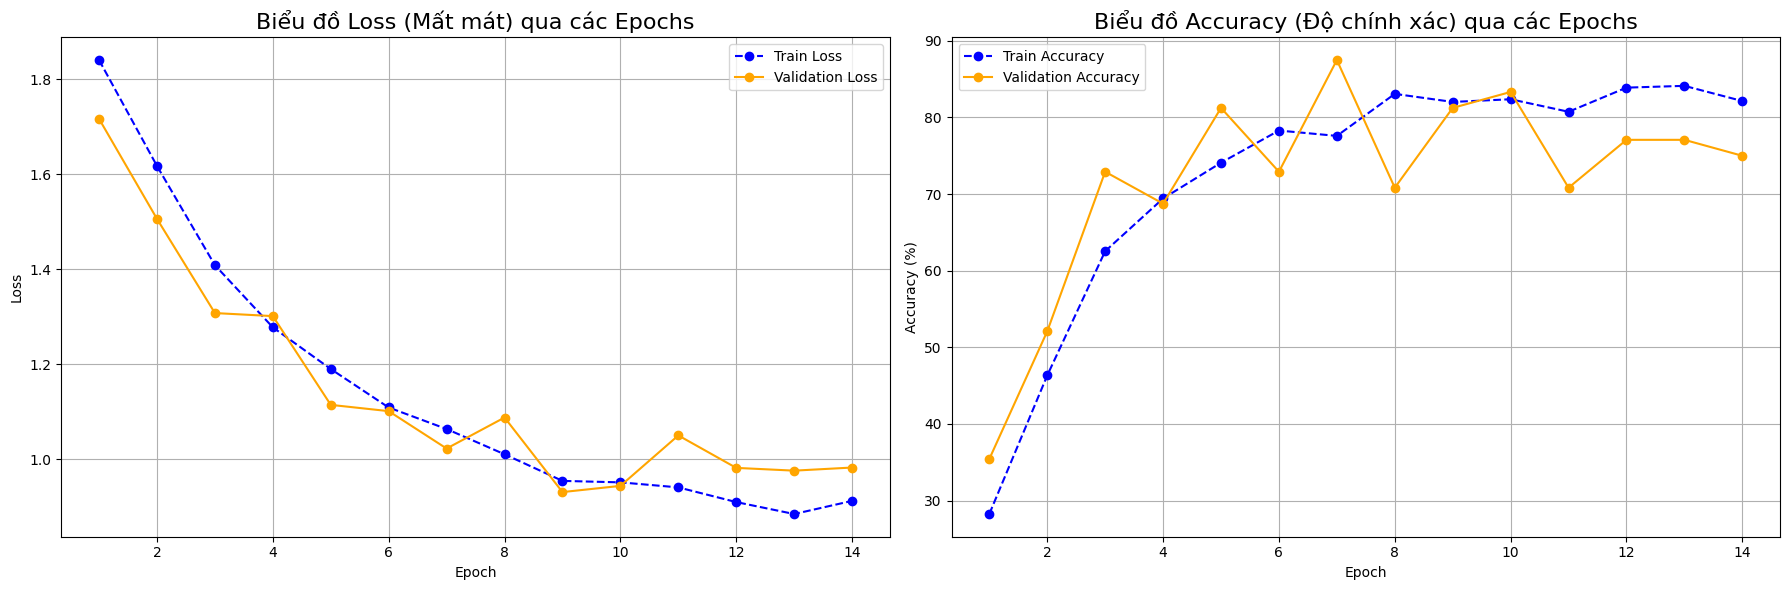

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    """
    Vẽ biểu đồ Loss và Accuracy từ history.
    (Phiên bản này tự động phát hiện số epochs)
    """

    # --- 1. Lấy dữ liệu từ history ---
    try:
        train_accu_list = history['train_acc']
        val_accu_list = history['val_acc']
        train_loss_list = history['train_loss']
        val_loss_list = history['val_loss']
    except KeyError as e:
        print(f"Lỗi: Không tìm thấy khóa {e} trong 'history'.")
        print("Hãy đảm bảo hàm 'fit' của bạn trả về dictionary với các khóa:")
        print("'train_acc', 'val_acc', 'train_loss', 'val_loss'")
        return

    # --- 2. TỰ ĐỘNG XÁC ĐỊNH SỐ EPOCHS (SỬA Ở ĐÂY) ---
    # Đo độ dài thực tế của history, đây chính là số epochs đã chạy
    actual_epochs_ran = len(train_accu_list)

    # Tạo danh sách các epoch (ví dụ: [1, 2, ..., 17])
    epochs_list = list(range(1, actual_epochs_ran + 1))

    # --- 3. Tạo 2 biểu đồ con (sub-plots) ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # --- Biểu đồ 1: Loss ---
    # (Tất cả code vẽ từ đây trở xuống không có gì thay đổi)
    ax1.plot(epochs_list, train_loss_list, label='Train Loss', color='blue', marker='o', linestyle='--')
    ax1.plot(epochs_list, val_loss_list, label='Validation Loss', color='orange', marker='o')
    ax1.set_title('Biểu đồ Loss (Mất mát) qua các Epochs', fontsize=16)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True) # Thêm lưới

    # --- Biểu đồ 2: Accuracy ---
    ax2.plot(epochs_list, train_accu_list, label='Train Accuracy', color='blue', marker='o', linestyle='--')
    ax2.plot(epochs_list, val_accu_list, label='Validation Accuracy', color='orange', marker='o')
    ax2.set_title('Biểu đồ Accuracy (Độ chính xác) qua các Epochs', fontsize=16)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)') # Cập nhật nhãn
    ax2.legend()
    ax2.grid(True) # Thêm lưới

    plt.tight_layout() # Tự động điều chỉnh layout

    plt.savefig('training_history_plot.png')
    print("\nĐã lưu biểu đồ vào file 'training_history_plot.png'")


# --- 3. Gọi hàm vẽ biểu đồ (SỬA Ở ĐÂY) ---
print("\n--- Đang vẽ biểu đồ Loss và Accuracy ---")

# Chỉ truyền history, KHÔNG truyền EPOCHS nữa
plot_history(history_mineral)